## 12. Mini Project: Combining Techniques
**Task:** Your goal is to produce the best possible version of the original image by combining the techniques you've learned.

1.	Start with a grey scale image
2.	Apply histogram equalisation
3.	Apply a smoothing filter
4.	Apply a sharpening filter
5.	Compare the original and final images

**Your explanation must reference:**
• Histogram processing

• Smoothing

• Sharpening

• The trade off between noise reduction and detail preservation


In [54]:
# imports 
import matplotlib.pyplot as plt
import numpy as np
import cv2
from scipy.ndimage import uniform_filter, laplace

### **Task1** 

Start with a grey scale image

Image size: (1920, 1080, 3)


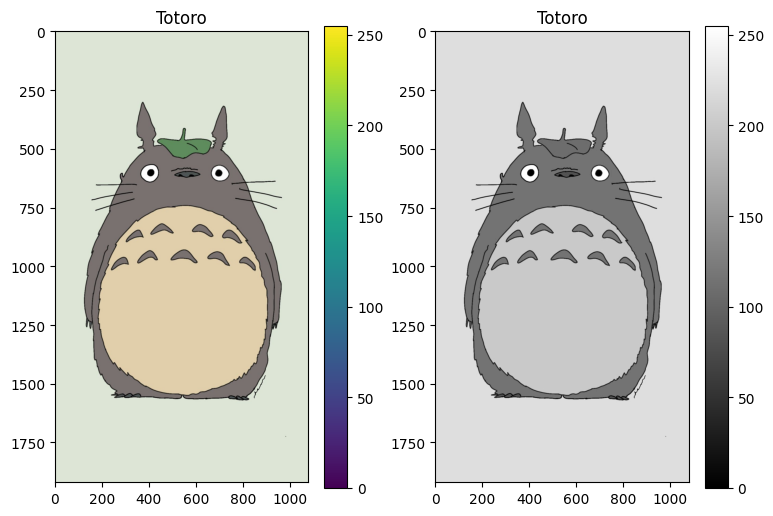

'Totoro is a magical forest spirit from the iconic Ghibli films'

In [60]:
# read image 
totoro = plt.imread('totoro.jpg')
print(f"Image size: {totoro.shape}")

# turn it to gray scale
gray_totoro = totoro.mean(axis=2)

# display it
plt.figure(figsize=(9,6))
plt.subplot(1,2,1); plt.imshow(totoro, vmin=0 ,vmax=255); plt.colorbar(); plt.title('Totoro')
plt.subplot(1,2,2); plt.imshow(gray_totoro, cmap='gray', vmin=0 ,vmax=255); plt.colorbar(); plt.title('Totoro')
plt.show()

'''Totoro is a magical forest spirit from the iconic Ghibli films'''

### **Task2** 

Apply histogram equalisation

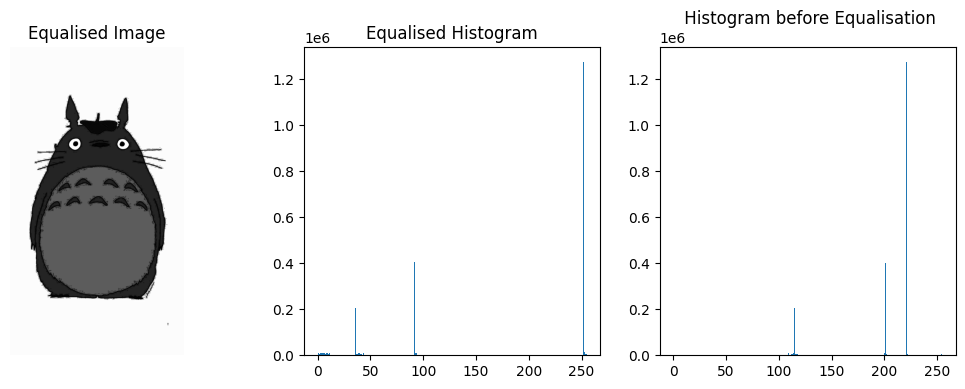

"Image I download from the web often be as type float64, \nwhich cannot be manipulated simply by image.astype(uint8). I learned that\nby applying a conversion function in lab1 and used cv2 to compare function's results"

In [61]:
def hist_equalise(img):
    hist, _ = np.histogram(img.flatten(), bins=256, range=(0,256))
    cdf = np.cumsum(hist)
    cdf_norm = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_norm = cdf_norm.astype(np.uint8) 
    return cdf_norm[img]

# change image type to uint8
gray_totoro = cv2.normalize(gray_totoro, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
equalised_totoro = hist_equalise(gray_totoro)

# Visual comparison
plt.figure(figsize=(13,4))

plt.subplot(1, 3, 1)
plt.imshow(equalised_totoro, cmap='gray', vmin=0, vmax=255)
plt.title("Equalised Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.hist(equalised_totoro.flatten(), bins=256, range=(0,255))
plt.title("Equalised Histogram")

plt.subplot(1, 3, 3)
plt.hist(gray_totoro.flatten(), bins=256, range=(0,255))
plt.title(" Histogram before Equalisation")
plt.show()

'''Image I download from the web often be as type float64, 
which cannot be manipulated simply by image.astype(uint8). I learned that
by applying a conversion function in lab1 and used cv2 to compare function's results'''

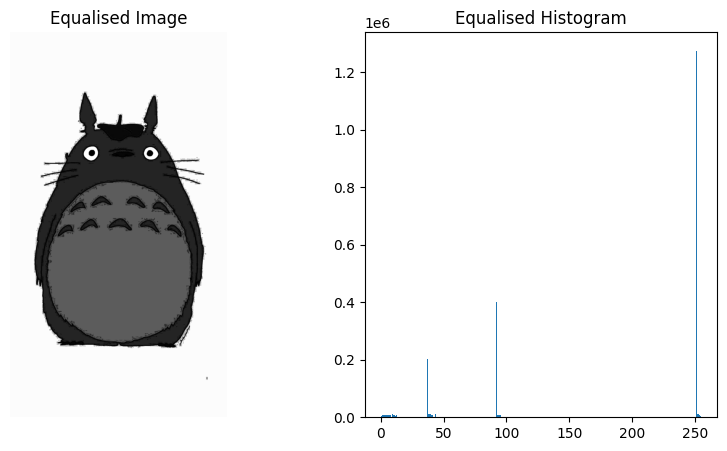

In [ ]:
# additional
# use cv2 histogram equiliser
equalised = cv2.equalizeHist(gray_totoro)

# display
plt.figure(figsize=(10,5)) 
plt.subplot(1,2,1); plt.imshow(equalised, cmap='gray'); plt.title("Equalised Image"); plt.axis('off')
plt.subplot(1,2,2); plt.hist(equalised.flatten(), bins=256, range=(0,255)); plt.title("Equalised Histogram") 
plt.show()

They appear to be the same!

### **Task3**

Apply a smoothing filter

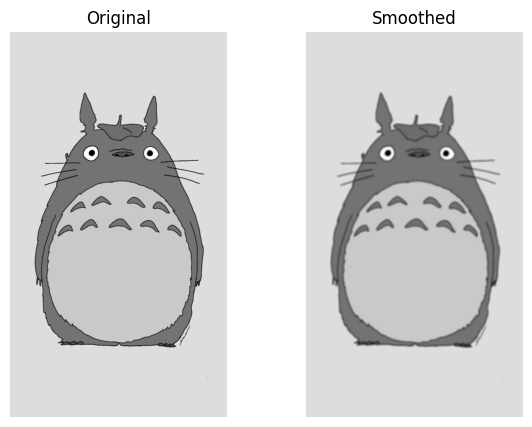

'Mean filter using 12x12 kernel size will pick 144 pixels and \naverage them to get thw new pixel value. I used a big sized kernel because \nthe image is super smooth and noise is absent'

In [62]:
# apply mean filter, kernel 3x3
totoro_smoothed = uniform_filter(gray_totoro, size=12)

# display
plt.figure(figsize=(7,5)) 
plt.subplot(1,2,1); plt.imshow(gray_totoro, cmap='gray'); plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(totoro_smoothed, cmap='gray'); plt.title("Smoothed"); plt.axis('off')
plt.show()

'''Mean filter using 12x12 kernel size will pick 144 pixels and 
average them to get thw new pixel value. I used a big sized kernel because 
the image is super smooth and noise is absent'''

### **Task4**

Apply a sharpening filter

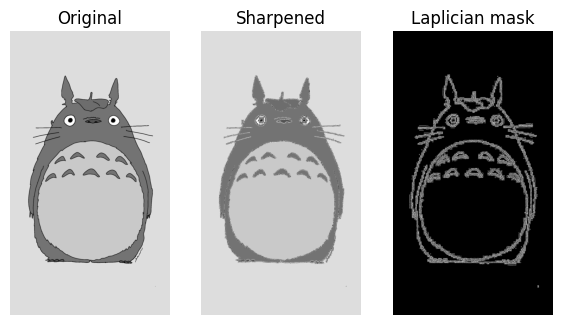

In [ ]:
# apply laplacian mask then subtract it from the original image to get the edges
lap = laplace(gray_totoro)
sharpened = gray_totoro - lap

# clipping will keep the intensity values in range (0-255) and discard values above or lower that range 
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

# display
plt.figure(figsize=(7,5)) 
plt.subplot(1,3,1); plt.imshow(gray_totoro, cmap='gray'); plt.title("Original"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(sharpened, cmap='gray'); plt.title("Sharpened"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(lap, cmap='gray'); plt.title("Laplician mask"); plt.axis('off')
plt.show()

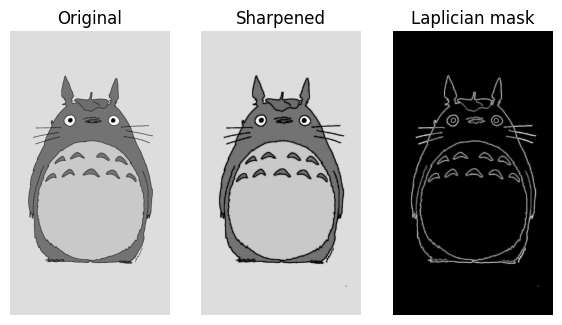

In [48]:
# apply laplacian sharpening using cv2
lap = cv2.Laplacian(gray_totoro, cv2.CV_16S, ksize=3)
lap = cv2.convertScaleAbs(lap)
sharpened = cv2.subtract(gray_totoro, lap)

# display
plt.figure(figsize=(7,5)) 
plt.subplot(1,3,1); plt.imshow(gray_totoro, cmap='gray'); plt.title("Original"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(sharpened, cmap='gray'); plt.title("Sharpened"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(lap, cmap='gray'); plt.title("Laplician mask"); plt.axis('off')
plt.show()

cv2 library produces dark edges while scipy laplace function does not.

## **Reflection questions**

**1.	Why does histogram equalisation sometimes over enhance images?**

Because it tries to distribute pixel intensities evenlly throughout the whole range. This way any clumps or grouped pixels around range of values are going to spread out which make the image look clearer.

**2.	Why is no single enhancement method sufficient in practice?**

Images suffer from different problems, and to each problem there is an enhancement technique that solves is efficiently. The real practical field demands the ability to pick the best enhancement method for the appropriate approach.

**3.	How does human perception influence what we consider a “good” enhancement?**

The human eye can detect details when image becomes blurry or unnatural due to its high ability to preserve the world clearly. Applying enhancement methods can be evaluated right away by comparing the original image to the enhanced one, and differences can be detected easily.